## Setup
Conexão com DuckDB e carregamento das tabelas Olist a partir dos CSVs originais.

In [136]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect()

data_path = "../data/raw"

con.execute(f"""
    CREATE TABLE orders AS SELECT * FROM read_csv_auto('{data_path}/olist_orders_dataset.csv');
    CREATE TABLE order_items AS SELECT * FROM read_csv_auto('{data_path}/olist_order_items_dataset.csv');
    CREATE TABLE customers AS SELECT * FROM read_csv_auto('{data_path}/olist_customers_dataset.csv');
    CREATE TABLE products AS SELECT * FROM read_csv_auto('{data_path}/olist_products_dataset.csv');
    CREATE TABLE sellers AS SELECT * FROM read_csv_auto('{data_path}/olist_sellers_dataset.csv');
    CREATE TABLE category_name_translation AS SELECT * FROM read_csv_auto('{data_path}/product_category_name_translation.csv');
    CREATE TABLE order_payments AS SELECT * FROM read_csv_auto('{data_path}/olist_order_payments_dataset.csv');
""")

print(con.execute("SHOW TABLES").fetchall())


[('category_name_translation',), ('customers',), ('order_items',), ('order_payments',), ('orders',), ('products',), ('sellers',)]


## Schema das Tabelas
Referência rápida das colunas disponíveis em cada tabela do dataset Olist.

In [137]:
con.execute("DESCRIBE orders").df()


,column_name,column_type,null,key,default,extra
0,order_id,VARCHAR,YES,None,None,None
1,customer_id,VARCHAR,YES,None,None,None
2,order_status,VARCHAR,YES,None,None,None
3,order_purchase_timestamp,TIMESTAMP,YES,None,None,None
4,order_approved_at,TIMESTAMP,YES,None,None,None
5,order_delivered_carrier_date,TIMESTAMP,YES,None,None,None
6,order_delivered_customer_date,TIMESTAMP,YES,None,None,None
7,order_estimated_delivery_date,TIMESTAMP,YES,None,None,None


In [138]:
con.execute("DESCRIBE order_items").df()


,column_name,column_type,null,key,default,extra
0,order_id,VARCHAR,YES,None,None,None
1,order_item_id,BIGINT,YES,None,None,None
2,product_id,VARCHAR,YES,None,None,None
3,seller_id,VARCHAR,YES,None,None,None
4,shipping_limit_date,TIMESTAMP,YES,None,None,None
5,price,DOUBLE,YES,None,None,None
6,freight_value,DOUBLE,YES,None,None,None


In [139]:
con.execute("DESCRIBE customers").df()


,column_name,column_type,null,key,default,extra
0,customer_id,VARCHAR,YES,None,None,None
1,customer_unique_id,VARCHAR,YES,None,None,None
2,customer_zip_code_prefix,VARCHAR,YES,None,None,None
3,customer_city,VARCHAR,YES,None,None,None
4,customer_state,VARCHAR,YES,None,None,None


In [140]:
con.execute("DESCRIBE products").df()


,column_name,column_type,null,key,default,extra
0,product_id,VARCHAR,YES,None,None,None
1,product_category_name,VARCHAR,YES,None,None,None
2,product_name_lenght,BIGINT,YES,None,None,None
3,product_description_lenght,BIGINT,YES,None,None,None
4,product_photos_qty,BIGINT,YES,None,None,None
5,product_weight_g,BIGINT,YES,None,None,None
6,product_length_cm,BIGINT,YES,None,None,None
7,product_height_cm,BIGINT,YES,None,None,None
8,product_width_cm,BIGINT,YES,None,None,None


In [141]:
con.execute("DESCRIBE sellers").df()


,column_name,column_type,null,key,default,extra
0,seller_id,VARCHAR,YES,None,None,None
1,seller_zip_code_prefix,VARCHAR,YES,None,None,None
2,seller_city,VARCHAR,YES,None,None,None
3,seller_state,VARCHAR,YES,None,None,None


In [142]:
con.execute("DESCRIBE category_name_translation").df()


,column_name,column_type,null,key,default,extra
0,product_category_name,VARCHAR,YES,None,None,None
1,product_category_name_english,VARCHAR,YES,None,None,None


In [143]:
con.execute("DESCRIBE order_payments").df()


,column_name,column_type,null,key,default,extra
0,order_id,VARCHAR,YES,None,None,None
1,payment_sequential,BIGINT,YES,None,None,None
2,payment_type,VARCHAR,YES,None,None,None
3,payment_installments,BIGINT,YES,None,None,None
4,payment_value,DOUBLE,YES,None,None,None


---
## Análises

## 1. Volume de pedidos por estado
Total de pedidos agrupado por estado do cliente, ordenado do maior pro menor.

In [144]:
con.execute("""
    SELECT
        customer_state,
        COUNT(order_id) AS total_pedidos
    FROM 
        orders 
    JOIN 
        customers ON orders.customer_id = customers.customer_id 
    GROUP BY 
        customer_state 
    ORDER BY 
        total_pedidos DESC;
""").df()


,customer_state,total_pedidos
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


> **Observação:** SP concentra a maior parte dos pedidos. Norte e Nordeste têm volume bem menor.

## 2. Distribuição por status
Quantidade de pedidos por status, ordenado do maior pro menor.

In [145]:
con.execute("""
    SELECT
        order_status,
        COUNT(order_id) AS total_pedidos
    FROM
        orders
    GROUP BY
        order_status
    ORDER BY
        total_pedidos DESC;
""").df()


,order_status,total_pedidos
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


> **Observação:** A grande maioria dos pedidos foi entregue. Cancelamentos e unavailable são minoria — mas existem.

## 3. Ticket médio por estado
Valor médio do preço dos itens agrupado por estado do cliente.

In [146]:
con.execute("""
    SELECT
        customer_state AS estado,
        AVG(price) AS ticket_medio
    FROM
        order_items
    JOIN
        orders ON order_items.order_id = orders.order_id
    JOIN 
        customers ON orders.customer_id = customers.customer_id
    GROUP BY 
        estado
    ORDER BY ticket_medio DESC;
""").df()


,estado,ticket_medio
0,PB,191.475216
1,AL,180.889212
2,AC,173.727717
3,RO,165.973525
4,PA,165.692417
5,AP,164.320732
6,PI,160.358081
7,TO,157.529333
8,RN,156.965936
9,CE,153.758261


> **Observação:** Estados com menos pedidos tendem a ter ticket médio maior. PB lidera, SP tem o menor ticket.

## 4. Top 10 produtos mais vendidos
Produtos com maior número de unidades vendidas na tabela order_items.

In [147]:
con.execute("""
    SELECT
        product_id,
        COUNT(*) AS quantidade_vendida
    FROM
        order_items
    GROUP BY
        product_id
    ORDER BY quantidade_vendida DESC
    LIMIT 10;
""").df()


,product_id,quantidade_vendida
0,aca2eb7d00ea1a7b8ebd4e68314663af,527
1,99a4788cb24856965c36a24e339b6058,488
2,422879e10f46682990de24d770e7f83d,484
3,389d119b48cf3043d311335e499d9c6b,392
4,368c6c730842d78016ad823897a372db,388
5,53759a2ecddad2bb87a079a1f1519f73,373
6,d1c427060a0f73f6b889a5c7c61f2ac4,343
7,53b36df67ebb7c41585e8d54d6772e08,323
8,154e7e31ebfa092203795c972e5804a6,281
9,3dd2a17168ec895c781a9191c1e95ad7,274


> **Observação:** Os IDs são hashes, então não dá pra identificar o produto diretamente. O volume entre os top 10 é bem próximo.

## 5. Top 10 sellers por itens vendidos
Sellers com maior volume de itens vendidos, identificados pelo seller_id.

In [148]:
con.execute("""
    SELECT
        seller_id,
        COUNT(*) AS itens_vendidos
    FROM
        order_items
    GROUP BY 
        seller_id
    ORDER BY itens_vendidos DESC
    LIMIT 10;
""").df()


,seller_id,itens_vendidos
0,6560211a19b47992c3666cc44a7e94c0,2033
1,4a3ca9315b744ce9f8e9374361493884,1987
2,1f50f920176fa81dab994f9023523100,1931
3,cc419e0650a3c5ba77189a1882b7556a,1775
4,da8622b14eb17ae2831f4ac5b9dab84a,1551
5,955fee9216a65b617aa5c0531780ce60,1499
6,1025f0e2d44d7041d6cf58b6550e0bfa,1428
7,7c67e1448b00f6e969d365cea6b010ab,1364
8,ea8482cd71df3c1969d7b9473ff13abc,1203
9,7a67c85e85bb2ce8582c35f2203ad736,1171


> **Observação:** O seller líder vendeu quase o dobro do 10º colocado. Há concentração no topo, mas sem um dominante absoluto.

## 6. Top 10 categorias por receita
Quais categorias geram mais receita total? Usamos um JOIN triplo entre `order_items`, `products` e `category_name_translation` para trazer o nome em inglês da categoria.

In [149]:
con.execute("""
    SELECT
        resumo_sb.category,
        resumo_sb.total
    FROM (
        SELECT
            c2.product_category_name_english AS category,
            SUM(price) AS total
        FROM 
            order_items AS o
        JOIN
            products AS p ON o.product_id = p.product_id
        JOIN 
            category_name_translation AS c2 ON p.product_category_name = c2.product_category_name
        GROUP BY 
            c2.product_category_name_english) AS resumo_sb
    ORDER BY total DESC
    LIMIT 10;
""").df()


,category,total
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


> **Observação:** `health_beauty` lidera em receita. `watches_gifts` aparece em segundo mesmo sem ser a categoria mais vendida em volume.

## 7. Classificação de pedidos por atraso na entrega
Usamos um CASE statement para categorizar cada pedido entregue como 'No Prazo', 'Atraso Leve' (1–7 dias) ou 'Atraso Crítico' (>7 dias), com base na diferença entre data estimada e data real de entrega.

In [150]:
df_shipping_status = con.execute("""
    SELECT
        CASE
            WHEN dias_gap <= 0 THEN 'No Prazo'
            WHEN dias_gap BETWEEN 1 AND 7 THEN 'Atraso Leve'
            ELSE 'Atraso Crítico'
        END AS status_entrega,
        COUNT(*) AS total_pedidos
    FROM (
        SELECT 
            order_id,
            date_diff('day', order_estimated_delivery_date, order_delivered_customer_date) AS dias_gap
        FROM
            orders
        WHERE 
            order_delivered_customer_date IS NOT NULL
    ) AS resumo_logistica
    GROUP BY 
        status_entrega;
""").df()

df_shipping_status.head()

,status_entrega,total_pedidos
0,No Prazo,89941
1,Atraso Leve,3672
2,Atraso Crítico,2863


> **Observação:** A maioria foi entregue no prazo. Atraso crítico existe, mas é minoria — a visualização abaixo mostra a proporção.

## 8. Meios de pagamento — volume e valor
Qual a participação de cada meio de pagamento no total de transações e na receita gerada?

In [151]:
con.execute("""
    SELECT 
        payment_type,
        COUNT(*)  AS total_category,
        ROUND(SUM(payment_value), 2) AS total_payment,
    FROM 
        order_payments
    WHERE 
        payment_type <> 'not_defined'
    GROUP BY 
        payment_type
    ORDER BY total_category DESC;
""").df()


,payment_type,total_category,total_payment
0,credit_card,76795,12542084.19
1,boleto,19784,2869361.27
2,voucher,5775,379436.87
3,debit_card,1529,217989.79


> **Observação:** Cartão de crédito domina — são 76k transações contra 19k de boleto. Em receita total a diferença é ainda maior: R$12,5M no crédito vs R$2,8M no boleto.

## 9. Detalhamento por tipo de pagamento
Ticket médio, média e mediana de parcelas por tipo de pagamento.

In [152]:
con.execute("""
    SELECT 
        payment_type,
        COUNT(payment_type) volume_transactions,
        ROUND(AVG(payment_value), 2) AS ticket,
        AVG(payment_installments) AS mean_installments,
        MEDIAN(payment_installments) AS median_installments,
        MAX(payment_installments) AS max_installments
    FROM 
        order_payments
    WHERE 
        payment_type = 'credit_card'
    GROUP BY 
        payment_type;
""").df()

,payment_type,volume_transactions,ticket,mean_installments,median_installments,max_installments
0,credit_card,76795,163.32,3.507155,3.0,24


> **Observação:** No crédito, a média de parcelas é ~3,5x e a mediana é 3x. Compras à vista no crédito ainda aparecem bastante (25k pedidos em 1x).

## 10. Distribuição por número de parcelas
Como o valor total e o volume de pedidos se distribuem pelo número de parcelas? Filtramos `credit_card` por ser o único meio que parcela.

In [156]:
df_installments = con.execute("""
    SELECT 
        payment_installments,
        ROUND(SUM(payment_value), 2) AS total_payment,
        ROUND(AVG(payment_value), 2) AS Average,
        COUNT(*) AS quantity_order_installments
    FROM 
        order_payments
    WHERE 
        payment_type = 'credit_card'
    AND
        payment_installments > 0
    GROUP BY
        payment_installments
    ORDER BY 
        payment_installments;
""").df()

df_installments.head(10)


,payment_installments,total_payment,Average,quantity_order_installments
0,1,2440445.43,95.87,25455
1,2,1579283.03,127.23,12413
2,3,1491103.80,142.54,10461
3,4,1163907.61,163.98,7098
4,5,961174.30,183.47,5239
5,6,822611.81,209.85,3920
6,7,305157.39,187.67,1626
7,8,1313423.34,307.74,4268
8,9,131015.92,203.44,644
9,10,2211577.34,415.09,5328


> **Observação:** Pedidos em 10x têm ticket médio de R$415 — quase 4x maior que compras à vista (R$95). Quanto mais parcelas, maior o valor da compra.

## Visualização — Distribuição de Status de Entrega

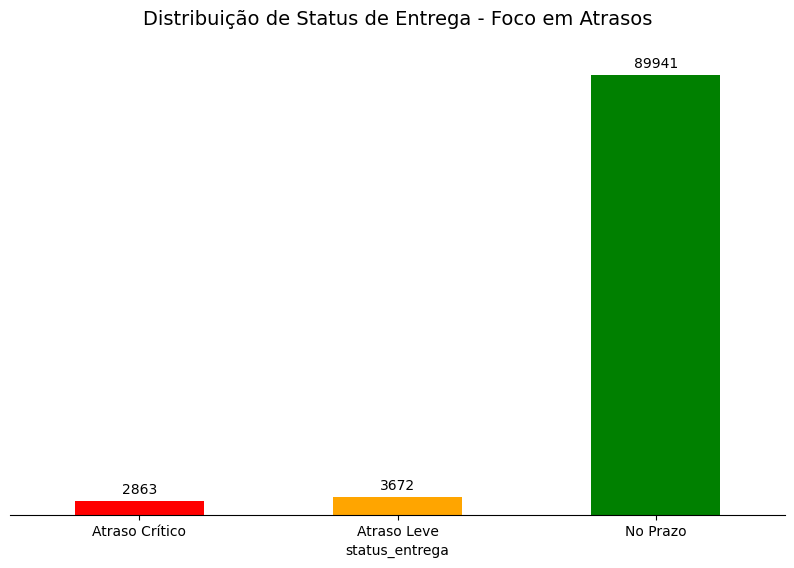

In [154]:
df_shipping_status = df_shipping_status.sort_values('total_pedidos')

ax = df_shipping_status.plot(kind='bar', x='status_entrega', y='total_pedidos', color=['red', 'orange', 'green'], legend=False, figsize=(10, 6))

ax.bar_label(ax.containers[0], padding=3)

ax.get_yaxis().set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.title('Distribuição de Status de Entrega - Foco em Atrasos', fontsize=14, pad=20)
plt.xticks(rotation=0)
plt.show()
